In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"Uploaded file: {file_name}")

df = pd.read_csv(file_name)

display(df.head())
print(df.shape)
print(df.columns)

Saving bengaluru_house_prices.csv to bengaluru_house_prices.csv
Uploaded file: bengaluru_house_prices.csv


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


(13320, 9)
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')


In [4]:
df = df[['location', 'size', 'total_sqft', 'bath', 'price']]
print(df.head())

                   location       size total_sqft  bath   price
0  Electronic City Phase II      2 BHK       1056   2.0   39.07
1          Chikka Tirupathi  4 Bedroom       2600   5.0  120.00
2               Uttarahalli      3 BHK       1440   2.0   62.00
3        Lingadheeranahalli      3 BHK       1521   3.0   95.00
4                  Kothanur      2 BHK       1200   2.0   51.00


In [5]:
df['bhk'] = df['size'].str.extract('(\d+)')
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1986/1429988353.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['bhk'] = df['size'].str.extract('(\d+)')


In [6]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return np.nan


df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [7]:
df = df.drop('size', axis=1)
df = df.dropna()
print(df.head())
print(df.shape)


                   location  total_sqft  bath   price  bhk
0  Electronic City Phase II      1056.0   2.0   39.07  2.0
1          Chikka Tirupathi      2600.0   5.0  120.00  4.0
2               Uttarahalli      1440.0   2.0   62.00  3.0
3        Lingadheeranahalli      1521.0   3.0   95.00  3.0
4                  Kothanur      1200.0   2.0   51.00  2.0
(13200, 5)


In [8]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bhk         13200 non-null  float64
dtypes: float64(4), object(1)
memory usage: 618.8+ KB
None
         total_sqft          bath         price           bhk
count  13200.000000  13200.000000  13200.000000  13200.000000
mean    1555.302783      2.691136    112.276178      2.800833
std     1237.323445      1.338915    149.175995      1.292843
min        1.000000      1.000000      8.000000      1.000000
25%     1100.000000      2.000000     50.000000      2.000000
50%     1275.000000      2.000000     71.850000      3.000000
75%     1672.000000      3.000000    120.000000      3.000000
max    52272.000000     40.000000   3600.000000     43.

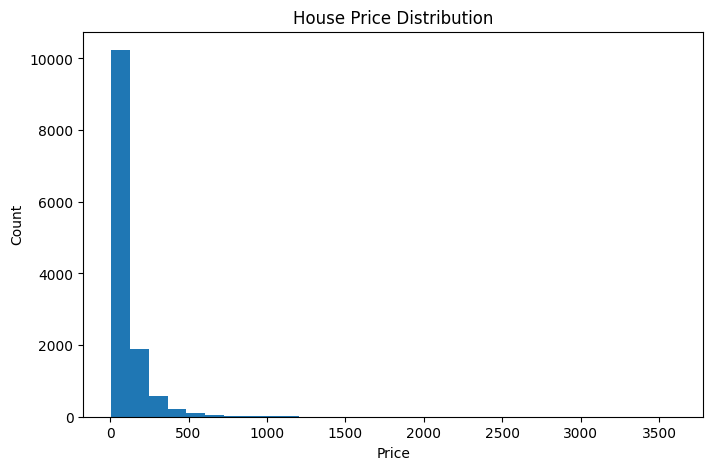

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title('House Price Distribution')
plt.show()

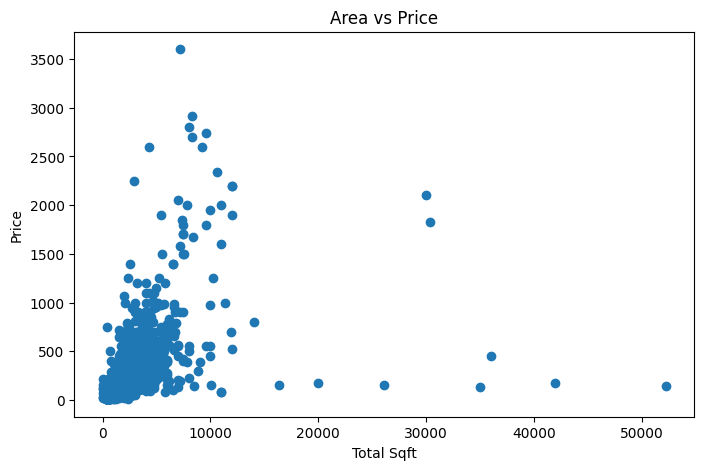

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['total_sqft'], df['price'])
plt.xlabel('Total Sqft')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()


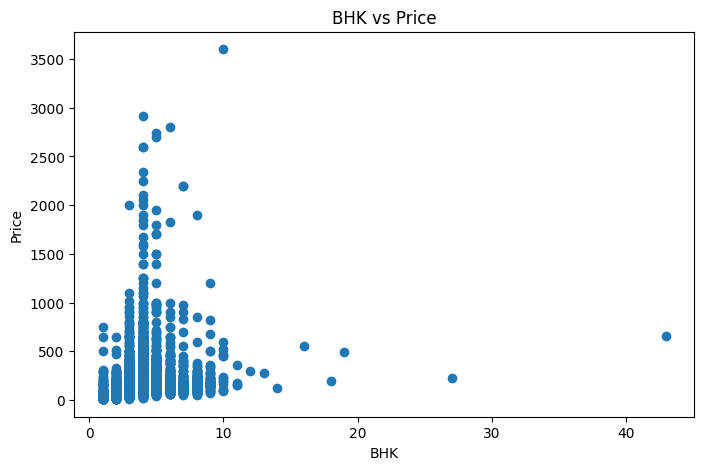

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df['bhk'], df['price'])
plt.xlabel('BHK')
plt.ylabel('Price')
plt.title('BHK vs Price')
plt.show()

In [12]:
X = df[['location', 'total_sqft', 'bath', 'bhk']]
y = df['price']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
categorical_features = ['location']
numerical_features = ['total_sqft', 'bath', 'bhk']

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

preprocessor = ColumnTransformer([
    ('cat', categorical_transformer, categorical_features),
    ('num', numerical_transformer, numerical_features)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [15]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  ['total_sqft', 'bath',
                                                   'bhk'])])),
                ('regressor', LinearRegression())])

In [16]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('R2 Score:', r2)

MAE: 41.573743348827264
MSE: 7485.893041418842
R2 Score: 0.5783049778851149


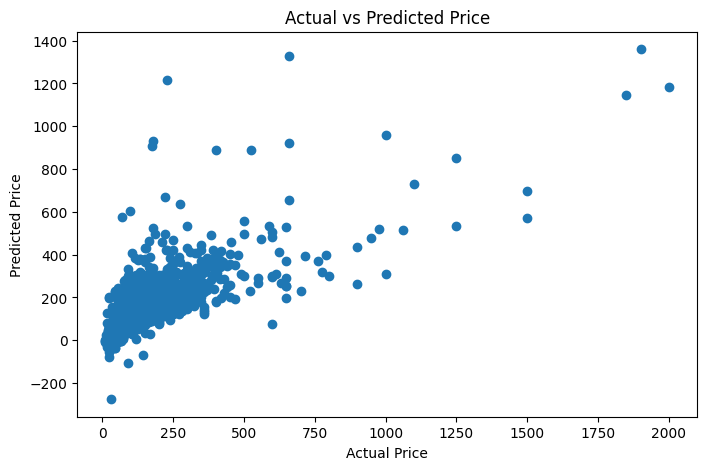

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

In [18]:
with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print('Model saved successfully')

Model saved successfully


In [19]:
!pip install gradio

In [20]:
import gradio as gr

with open('house_price_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [21]:
def predict_price(location, total_sqft, bath, bhk):
    input_data = pd.DataFrame({
        'location': [location],
        'total_sqft': [float(total_sqft)],
        'bath': [float(bath)],
        'bhk': [float(bhk)]
    })

    prediction = loaded_model.predict(input_data)[0]

    if prediction >= 100:
        price_cr = prediction / 100
        return f"Estimated Property Price: ₹ {round(price_cr, 2)} Cr"
    else:
        return f"Estimated Property Price: ₹ {round(prediction, 2)} Lakhs"

In [22]:
location_list = sorted(df['location'].unique().tolist())

In [39]:
custom_css = """
body {
    background: url('https://images.unsplash.com/photo-1486406146926-c627a92ad1ab?auto=format&fit=crop&w=1400&q=80');
    background-size: cover;
    background-position: center;
    background-attachment: fixed;
}

.gradio-container {
    max-width: 1250px !important;
    margin: auto;
    margin-top: 20px;
    padding: 30px;
    border-radius: 25px;
    background: rgba(15, 23, 42, 0.92);
    font-family: Arial, sans-serif;
}

.main-title {
    text-align: center;
    font-size: 45px;
    font-weight: bold;
    color: white;
    margin-bottom: 8px;
}

.sub-title {
    text-align: center;
    font-size: 18px;
    color: #cbd5e1;
    margin-bottom: 30px;
}

.card {
    background: rgba(255, 255, 255, 0.08);
    backdrop-filter: blur(12px);
    -webkit-backdrop-filter: blur(12px);
    border: 1px solid rgba(255, 255, 255, 0.15);
    border-radius: 20px;
    padding: 25px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.4);
}

.result-card {
    background: rgba(37, 99, 235, 0.18);
    backdrop-filter: blur(14px);
    -webkit-backdrop-filter: blur(14px);
    border: 1px solid rgba(255,255,255,0.2);
    border-radius: 20px;
    padding: 30px;
    min-height: 320px;
    box-shadow: 0 10px 25px rgba(0,0,0,0.4);
}

#output-box {
    background: rgba(255,255,255,0.9) !important;
    border: 2px solid white !important;
    border-radius: 15px !important;
}

#output-box textarea {
    background: transparent !important;
    color: black !important;
    font-size: 32px !important;
    font-weight: bold !important;
    text-align: center !important;
    border: none !important;
    box-shadow: none !important;
}

button {
    background: linear-gradient(90deg, #2563eb, #3b82f6) !important;
    color: white !important;
    border: none !important;
    border-radius: 12px !important;
    font-size: 18px !important;
    font-weight: bold !important;
    padding: 14px !important;
    transition: 0.3s ease;
}

button:hover {
    transform: scale(1.03);
}

label {
    color: #e2e8f0 !important;
    font-size: 15px !important;
    font-weight: 600 !important;
}

.footer-text {
    text-align: center;
    color: #cbd5e1;
    margin-top: 25px;
    font-size: 14px;
}
"""

with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:

    gr.Markdown("""
    <div style='text-align:center; margin-bottom:25px;'>
        <div style='font-size:60px;'>🏠</div>
        <div class='main-title'>Bengaluru Property Price Predictor</div>
        <div class='sub-title'>
        Discover the Estimated Buying Price of Your Dream Home Instantly
        </div>
    </div>
    """)

    with gr.Row():

        with gr.Column(scale=2):
            with gr.Group(elem_classes="card"):

                gr.Markdown("## Enter Property Details")

                location = gr.Dropdown(
                    choices=location_list,
                    label="📍 Location",
                    info="Choose the area where the property is located"
                )

                total_sqft = gr.Number(
                    label="📐 Total Area (Sqft)",
                    placeholder="Example: 1200",
                    info="Enter the total built-up area in square feet"
                )

                bhk = gr.Number(
                    label="🛏️ Bedrooms (BHK)",
                    placeholder="Example: 3",
                    info="Enter total number of bedrooms"
                )

                bath = gr.Number(
                    label="🚿 Bathrooms",
                    placeholder="Example: 2",
                    info="Enter total number of bathrooms"
                )

                with gr.Row():
                    predict_btn = gr.Button("Predict Property Price")
                    reset_btn = gr.Button("Reset")

        with gr.Column(scale=1):
            with gr.Group(elem_classes="result-card"):

                gr.Markdown("""
                <div style='text-align:center;'>
                    <h2 style='color:black; font-size:30px;'>Estimated Price</h2>
                    <p style='color:black; font-size:15px;'>
                     Your predicted property price will appear below
                    </p>
                </div>
                """)

                output = gr.Textbox(
                    value="Waiting for prediction...",
                    label="Predicted Price",
                    elem_id="output-box",
                    lines=2,
                    interactive=False,
                    visible=True
                )

    predict_btn.click(
        fn=lambda: "Predicting Property Price...",
        inputs=[],
        outputs=output
    ).then(
        fn=predict_price,
        inputs=[location, total_sqft, bath, bhk],
        outputs=output
    )

    reset_btn.click(
        fn=lambda: ("", None, None, None, "Waiting for prediction..."),
        inputs=[],
        outputs=[location, total_sqft, bath, bhk, output]
    )

    gr.Markdown("""
    <div class='footer-text'>
    Powered by Linear Regression Model | Real Estate Price Estimation System
    </div>
    """)

demo.launch()

/tmp/ipykernel_1986/1783887624.py:100: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:
/tmp/ipykernel_1986/1783887624.py:100: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, theme=gr.themes.Base()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a421c900f0ea3f9bda.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
